In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os
import sys
import pickle
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
import spk_feat_cluster_comp_analysis
importlib.reload(spk_feat_cluster_comp_analysis)
from spk_feat_cluster_comp_analysis import (
    compile_experiment_results,
    compute_whole_recording_psds,
    plot_lfp_psd_by_feature_group,
    plot_lfp_metrics_by_feature_group,
)
import config

CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'
LFP_NPY_DIR     = os.path.join(config.SPE1_DATA_ROOT, 'filt_lfp_recordings')

In [2]:
df_transitions = pd.read_pickle(CLUSTER_PKL_DIR + 'temporal_transitions.pkl')

from collections import Counter
print(f'{len(df_transitions)} transition events across '
      f'{df_transitions.cell_id.nunique()} cells')
for feat, cnt in sorted(Counter(df_transitions.spike_feature).items()):
    print(f'  {feat:<22} n = {cnt}')

52 transition events across 27 cells
  exp_lambda             n = 8
  inflection_time        n = 4
  log_isi                n = 8
  peak_amp               n = 15
  peak_sharpness         n = 6
  peak_width             n = 11


## LFP spectra by spike-feature cluster type

**Question**: does the LFP oscillatory environment differ between cells that show cluster
transitions in different spike features?

For each cell, the **full recording** LFP is used — this captures the global oscillatory
regime of the recording rather than the local dynamics at the transition moment.
Cells with no detected transitions in any feature are included as a reference group.

**Normalization**: within each feature group, per-cell mean PSD is subtracted and the
feature-group grand mean is added back, preserving between-group spectral shape differences
while removing between-cell amplitude differences.

In [3]:
_WHOLE_PKL = CLUSTER_PKL_DIR + 'lfp_whole_recording_psds.pkl'

whole_results = compute_whole_recording_psds(
    df_transitions, LFP_NPY_DIR,
    include_no_transition=True,
    save_path=_WHOLE_PKL, force=False,
)

Loaded cached whole-recording PSDs from /Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/lfp_whole_recording_psds.pkl


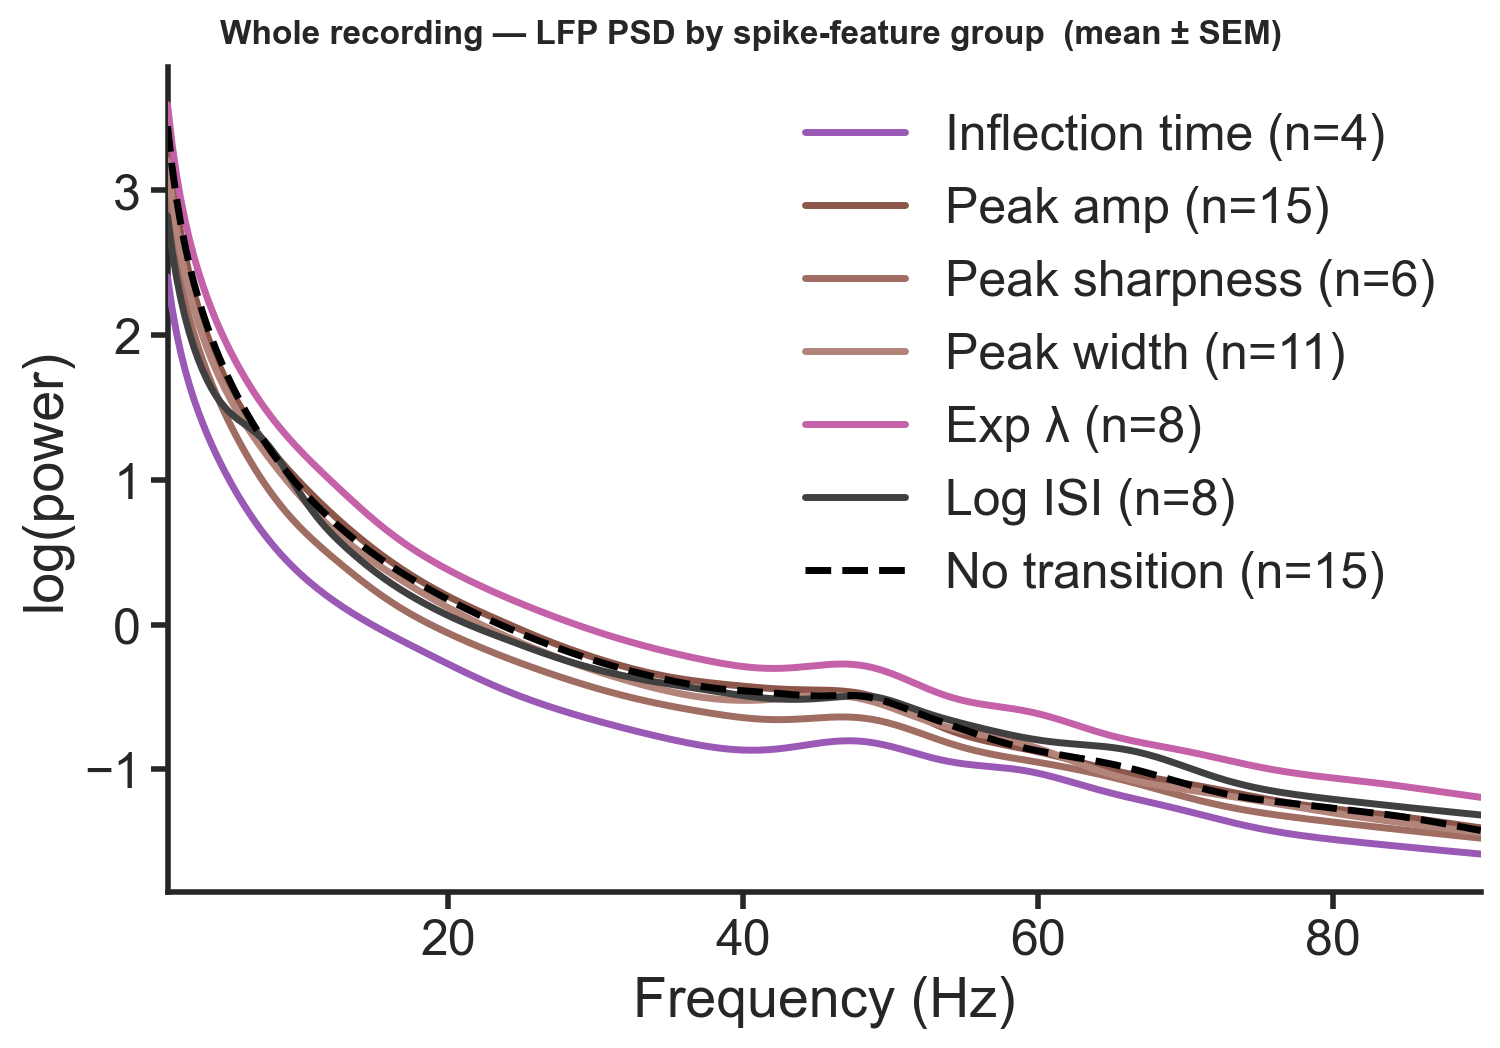

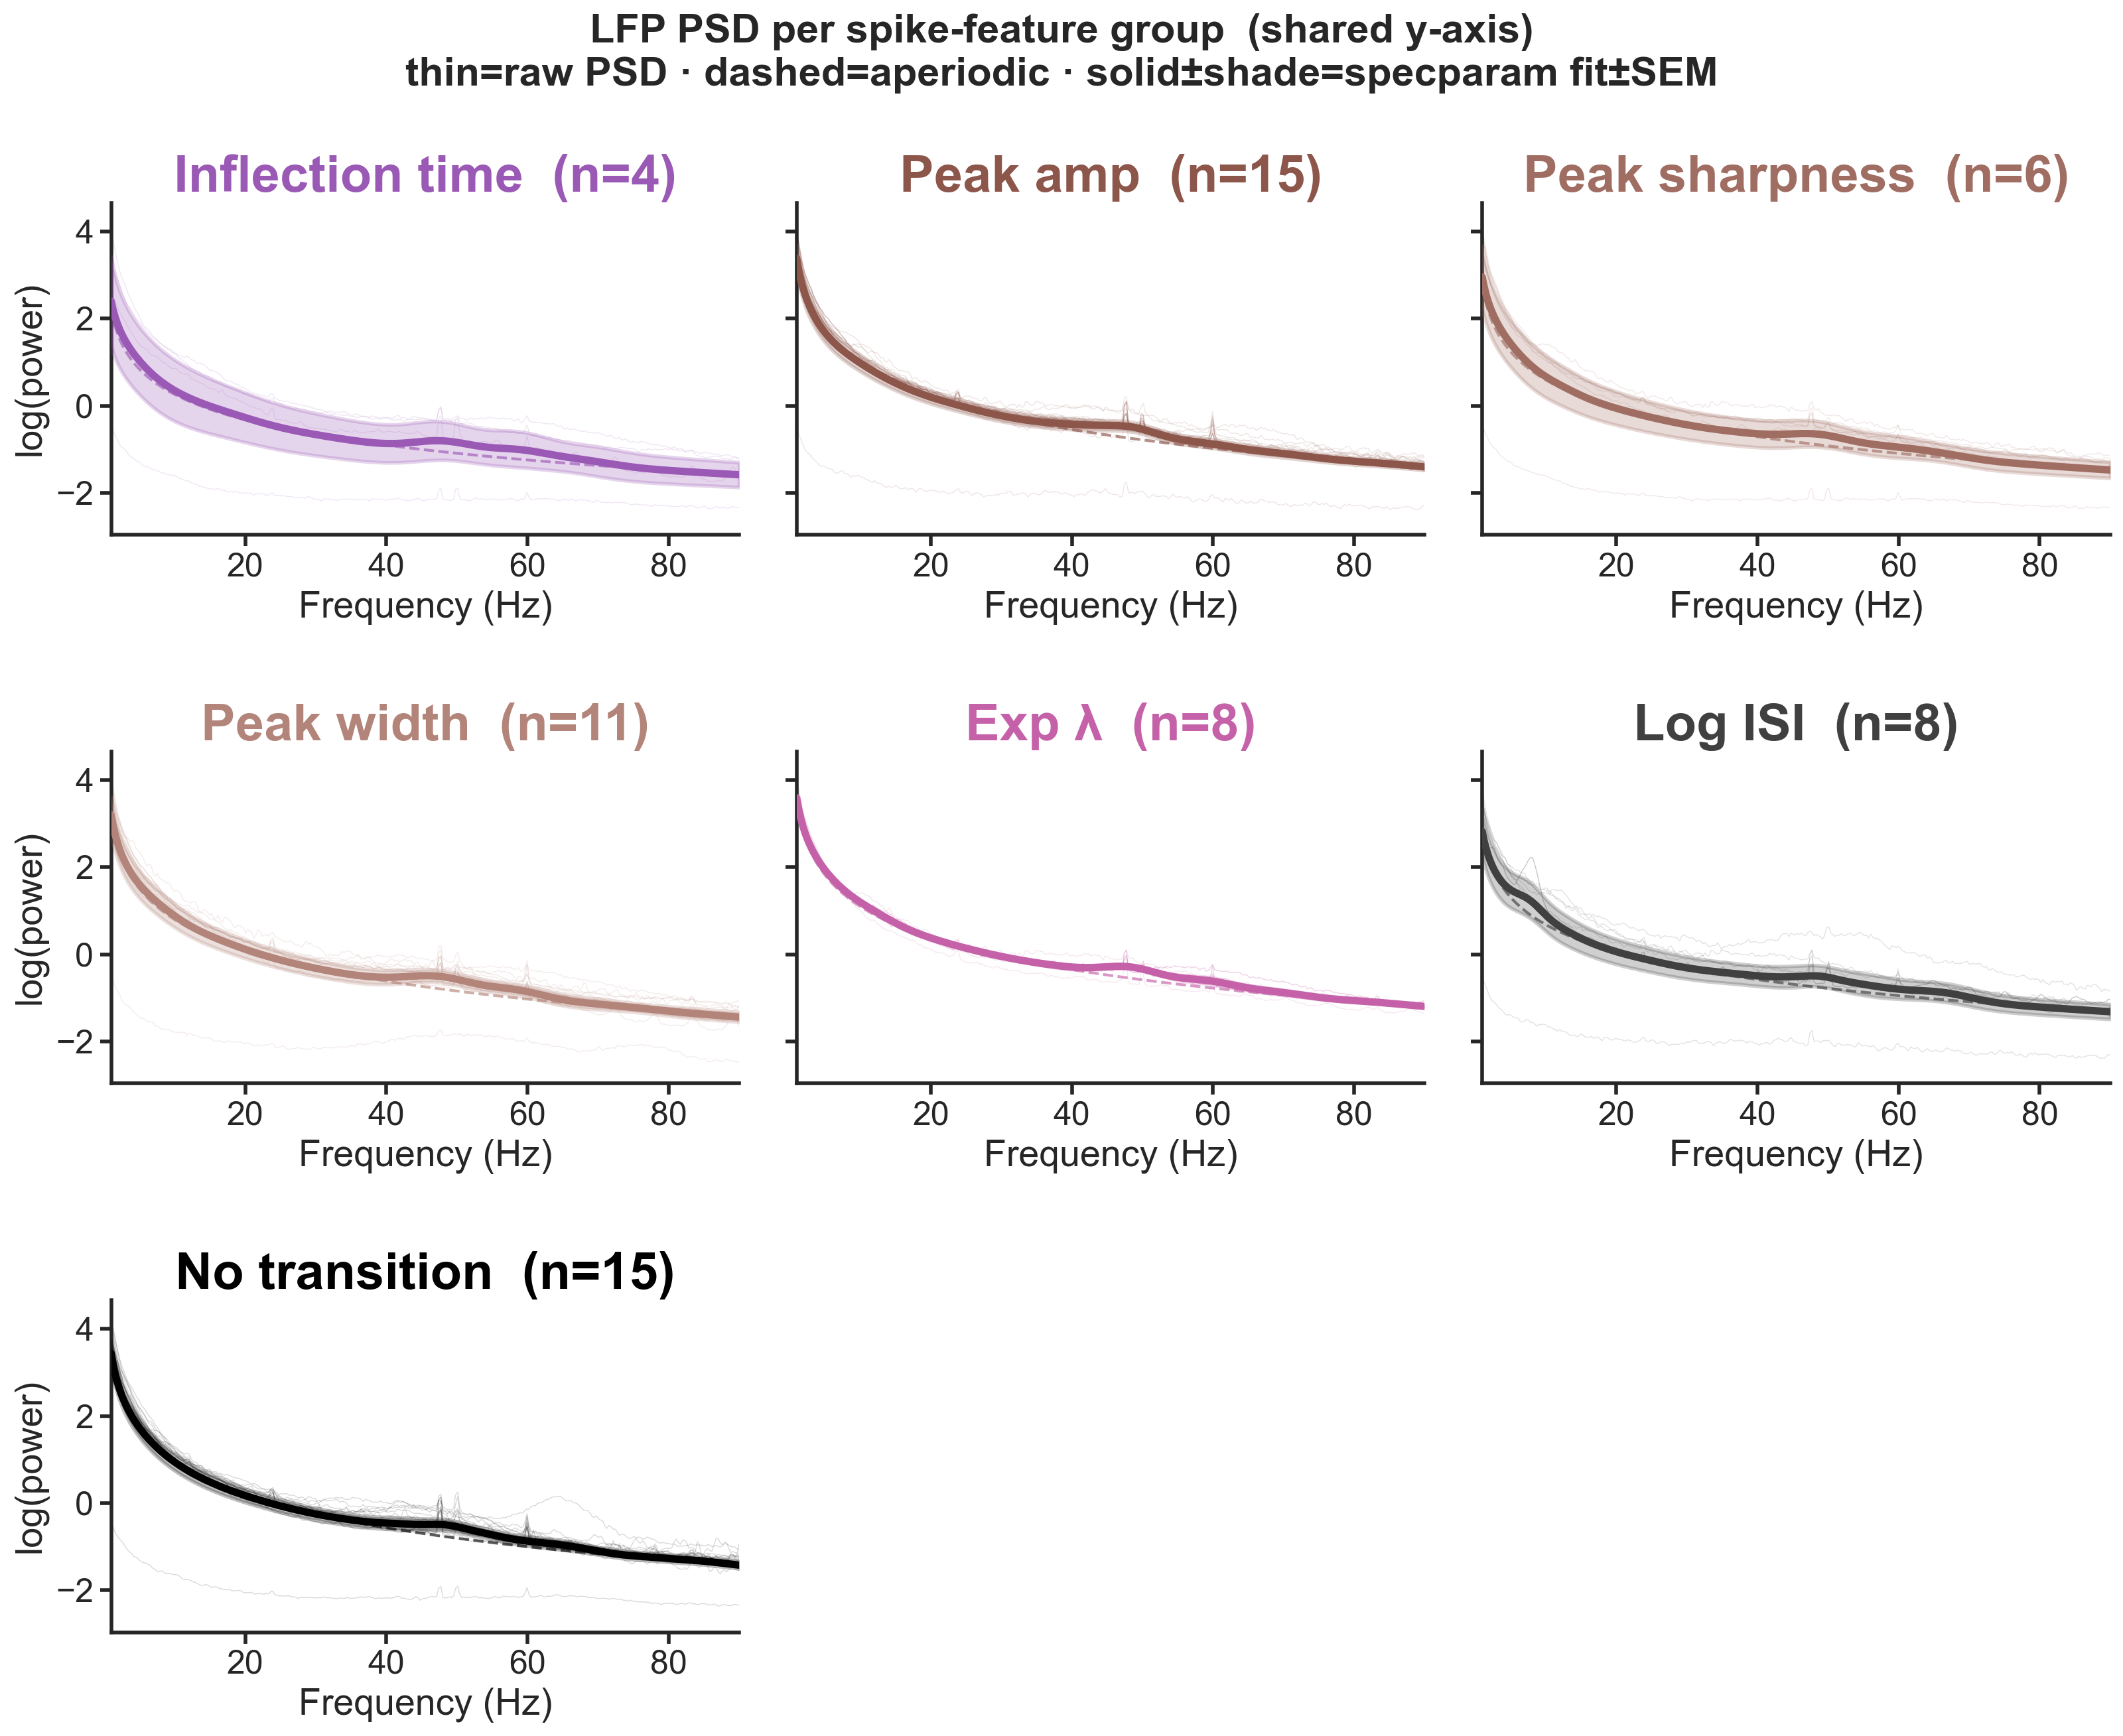

In [4]:
# Overlay: all feature groups on one axes
fig_ov, fig_gr = plot_lfp_psd_by_feature_group(
    whole_results, df_transitions,
    freq_range=(1, 90),
)
fig_ov.suptitle('Whole recording — LFP PSD by spike-feature group  (mean ± SEM)',
                fontsize=12, fontweight='bold')
plt.show()

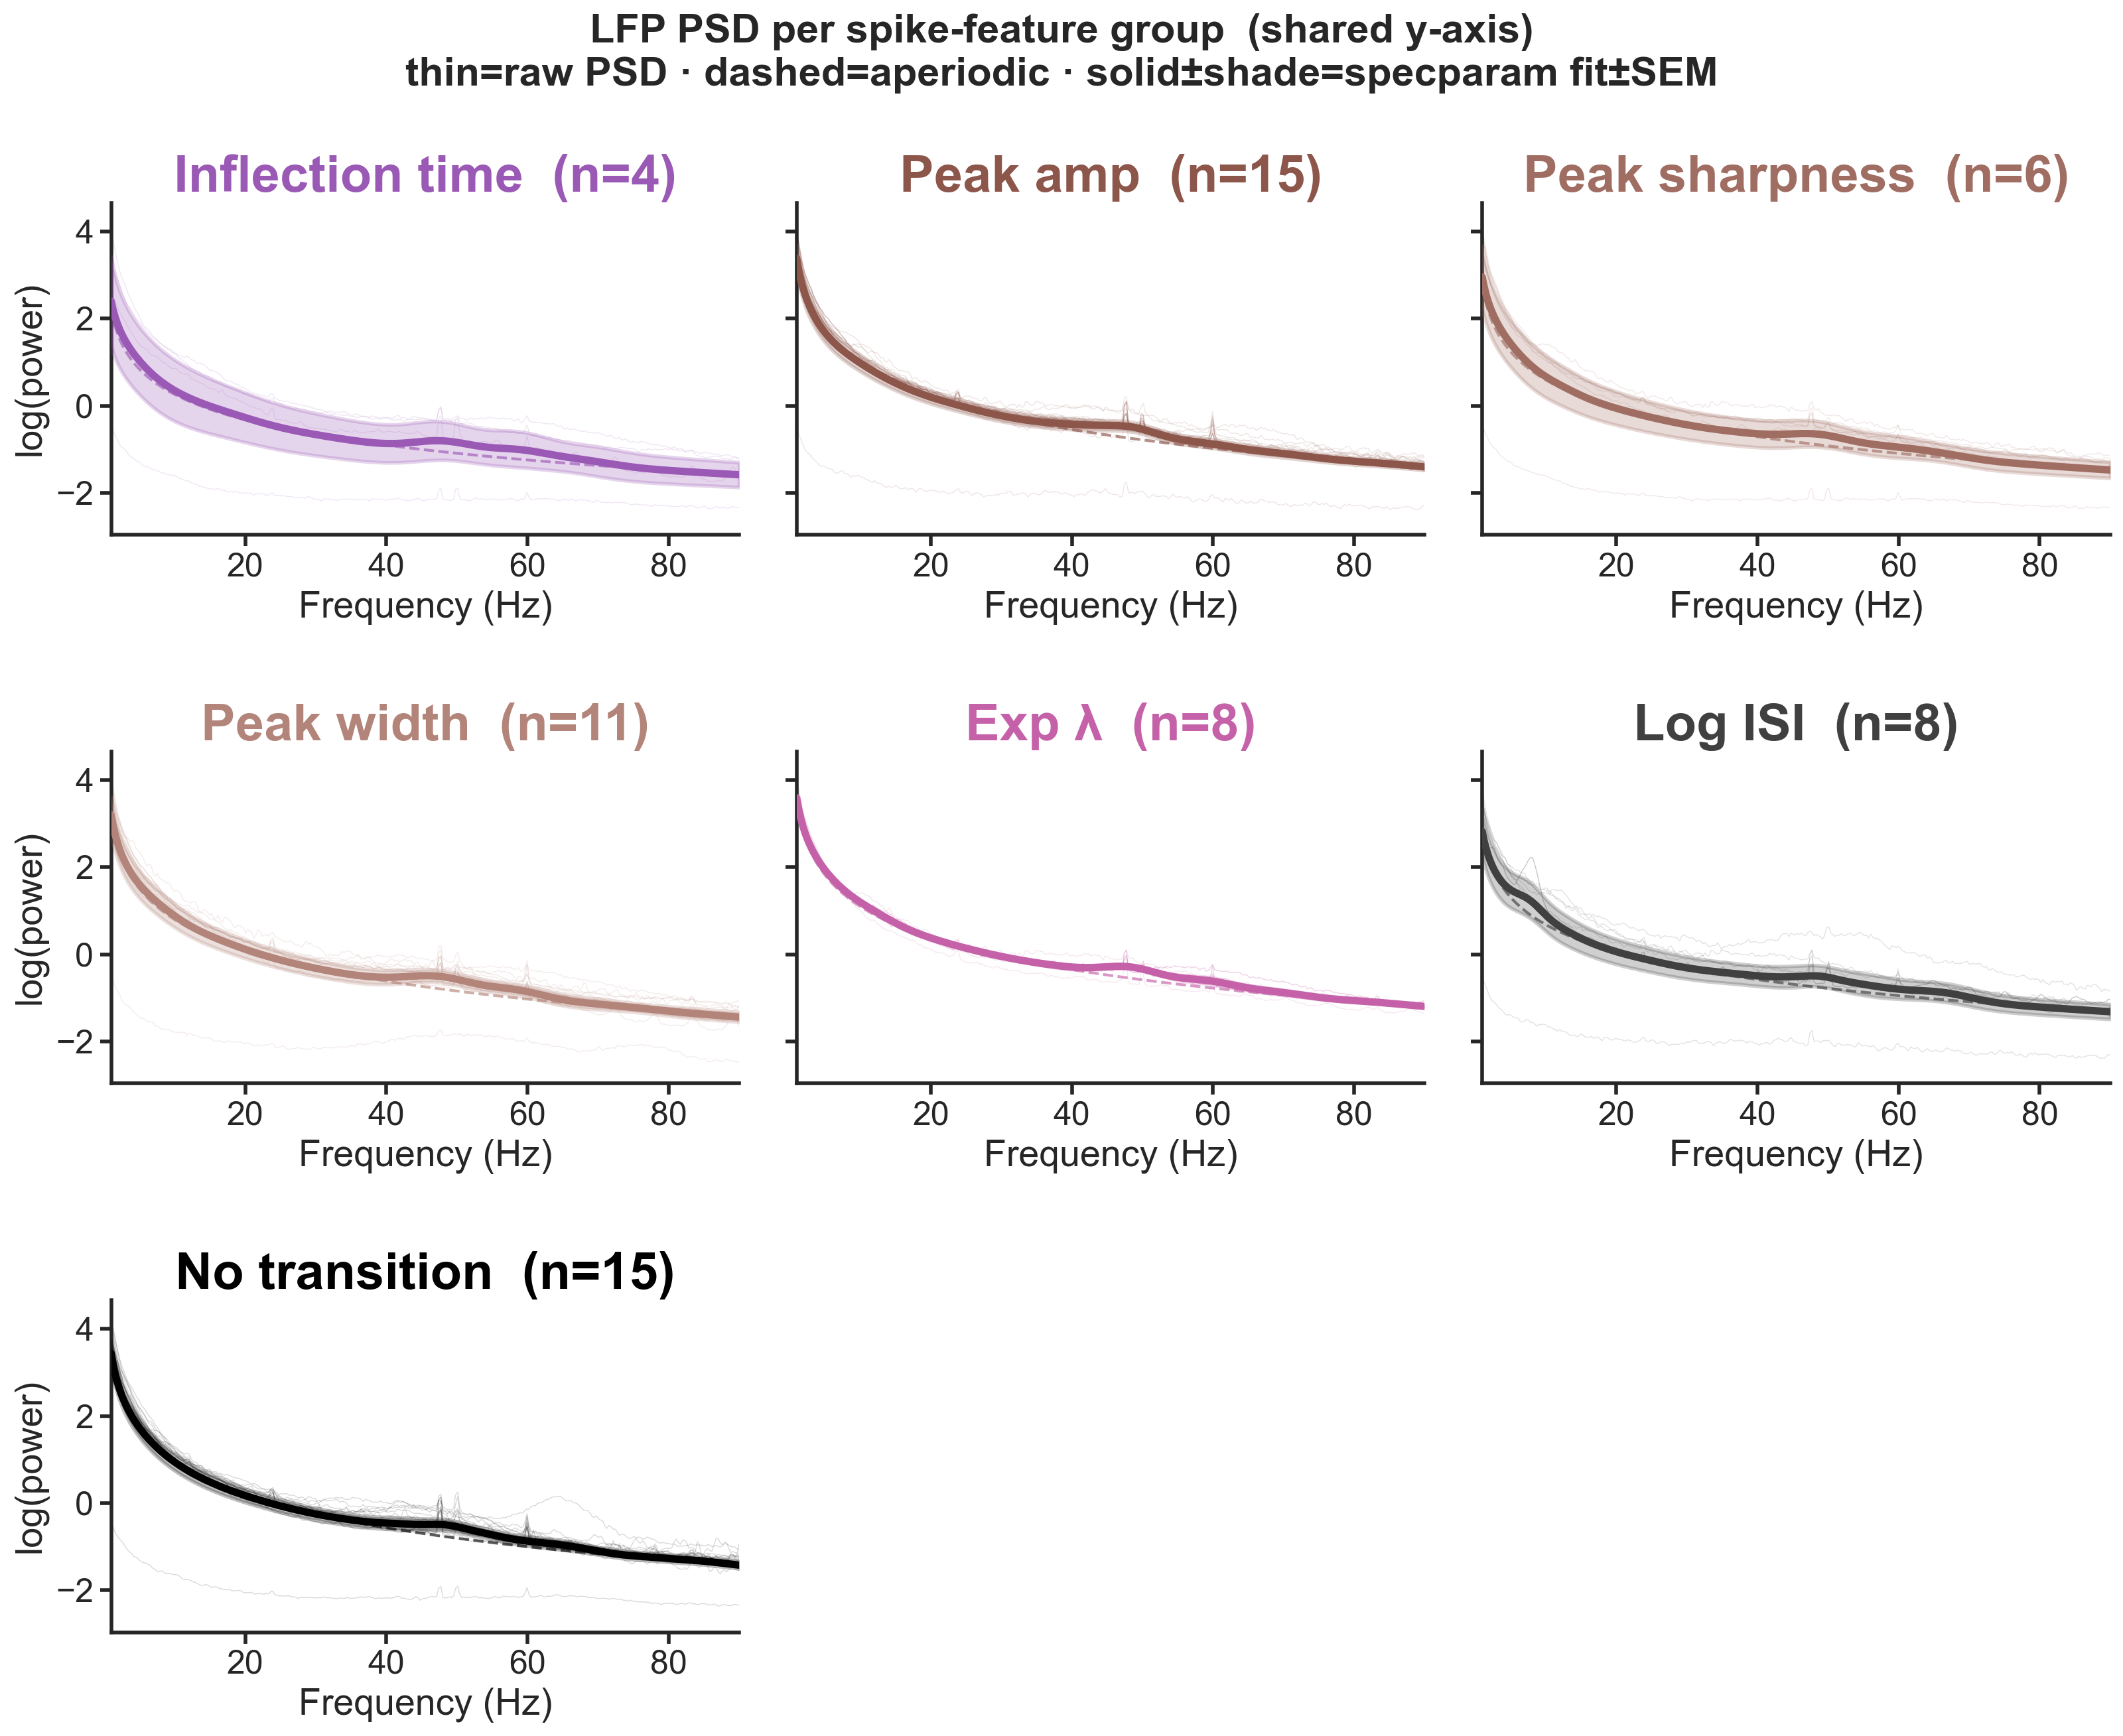

In [5]:
# Per-feature grid (shared y-axis)
display(fig_gr)
plt.show()

In [ ]:
# Scalar LFP metrics per feature group — whole recording
fig_met_whole = plot_lfp_metrics_by_feature_group(whole_results)
plt.show()

**Supplementary Figure X. LFP activity by spike feature cluster transitions.**

*(A)* LFP power spectra computed over the full recording for each cell, with cells separated by which spike waveform feature exhibits cluster state transitions. Top left: overlay of mean specparam model fits across all feature groups; cells with no detected transitions in any feature are shown as a dashed black reference line. Top right and bottom grid: per-group mean ± SEM specparam fits (colored lines ± shading), with individual-cell raw PSDs shown as thin semi-transparent lines in the background. n = number of cells per group.

*(B)* Scalar LFP metrics for each spike feature group derived from the same whole-recording specparam fits: aperiodic exponent and offset, mean and standard deviation of broadband amplitude, and area under the periodic component in the theta (4–15 Hz) and gamma (30–80 Hz) bands. Each dot represents one cell; crosshairs indicate group mean ± SEM. Stars in panel titles indicate a significant difference across groups (Kruskal–Wallis test; \* p < 0.05, \*\* p < 0.01). Aperiodic exponent differed significantly across groups (H(6) = 16.98, p = 0.009), as did aperiodic offset (H(6) = 13.21, p = 0.040) and theta AUC (H(6) = 12.73, p = 0.048). Broadband amplitude and gamma AUC did not differ significantly across groups.